## loading necessary libs

In [1]:
# !pip install "alphatims[plotting]"
# !pip install hvplot
# !pip install jupyter_bokeh
# !pip install dask[dataframe]
# !pip install matplotlib
# !pip install scikit-learn

In [2]:
import alphatims.utils
import alphatims.bruker
import alphatims.plotting
import importlib
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN

from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
import seaborn as sns



### Loading Data

In [3]:


alphatims.utils.set_threads(4)
log_file_name = alphatims.utils.set_logger(
    log_file_name="tutorial_log.txt",
    overwrite=True
)

def reload():
    importlib.reload(alphatims.utils)
    importlib.reload(alphatims.bruker)
    importlib.reload(alphatims.plotting)
    alphatims.utils.set_threads(4)
    alphatims.utils.set_logger(log_file_name="tutorial_log.txt")
    
isDia = True

if (isDia):
    bruker_d_folder_name = "../MS_Data/test1.hdf"
    
else :
    bruker_d_folder_name = ""

data = alphatims.bruker.TimsTOF(bruker_d_folder_name)

2025-04-01 02:58:25> Importing data from ../MS_Data/test1.hdf
2025-04-01 02:58:25> Using HDF import for ../MS_Data/test1.hdf
2025-04-01 02:58:30> Successfully imported data from ../MS_Data/test1.hdf


In [4]:
selected_indices = data[:,:,0, 400.0: 425.0,"raw"]

In [5]:

# intensities =data.bin_intensities(selected_indices,("rt_values","mz_values"))
# intensities

## Plotting

In [6]:
def plot_lineplot(x_dim,y_dim,selected_indices):
        if data is not None:  # Ensure dataset is loaded
            # Validate selected dimensions
            valid_x_dims = ['mz', 'rt', 'mobility']
            valid_y_dims = ['intensity', 'mz', 'rt', 'mobility']
            if x_dim in valid_x_dims and y_dim in valid_y_dims: 
                # Create the plot
                plot = alphatims.plotting.line_plot(
                    data,
                    selected_indices,
                    x_dim,
                    data.sample_name,
                    y_dim
                )
                print("acquisition_mode: ",data.acquisition_mode)
                return plot  # Dynamically update the plot
            else:
                return "Invalid dimensions selected."
        else:
            return "Dataset is not loaded."

In [7]:
dimensions = ("rt_values","mz_values")
intensities = data.bin_intensities(selected_indices, dimensions)
intensities

max_index :  {'rt_values': 3177, 'mobility_values': 928, 'mz_values': 394536}
parsed_indices :  {'frame_indices': array([   1,    1,    1, ..., 3176, 3176, 3176]), 'tof_indices': array([127662, 132644, 130823, ..., 128881, 129883, 133525], dtype=uint32)}


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [8]:
intensities.shape
np.linspace(0, 197268 - 1, num=100, dtype=int)


array([     0,   1992,   3985,   5977,   7970,   9962,  11955,  13948,
        15940,  17933,  19925,  21918,  23911,  25903,  27896,  29888,
        31881,  33874,  35866,  37859,  39851,  41844,  43837,  45829,
        47822,  49814,  51807,  53800,  55792,  57785,  59777,  61770,
        63763,  65755,  67748,  69740,  71733,  73726,  75718,  77711,
        79703,  81696,  83689,  85681,  87674,  89666,  91659,  93652,
        95644,  97637,  99629, 101622, 103614, 105607, 107600, 109592,
       111585, 113577, 115570, 117563, 119555, 121548, 123540, 125533,
       127526, 129518, 131511, 133503, 135496, 137489, 139481, 141474,
       143466, 145459, 147452, 149444, 151437, 153429, 155422, 157415,
       159407, 161400, 163392, 165385, 167378, 169370, 171363, 173355,
       175348, 177341, 179333, 181326, 183318, 185311, 187304, 189296,
       191289, 193281, 195274, 197267])

[     0   3985   7970  11955  15940  19926  23911  27896  31881  35866
  39852  43837  47822  51807  55792  59778  63763  67748  71733  75718
  79704  83689  87674  91659  95644  99630 103615 107600 111585 115570
 119556 123541 127526 131511 135496 139482 143467 147452 151437 155422
 159408 163393 167378 171363 175348 179334 183319 187304 191289 195274
 199260 203245 207230 211215 215200 219186 223171 227156 231141 235126
 239112 243097 247082 251067 255052 259038 263023 267008 270993 274978
 278964 282949 286934 290919 294904 298890 302875 306860 310845 314830
 318816 322801 326786 330771 334756 338742 342727 346712 350697 354682
 358668 362653 366638 370623 374608 378594 382579 386564 390549 394535]


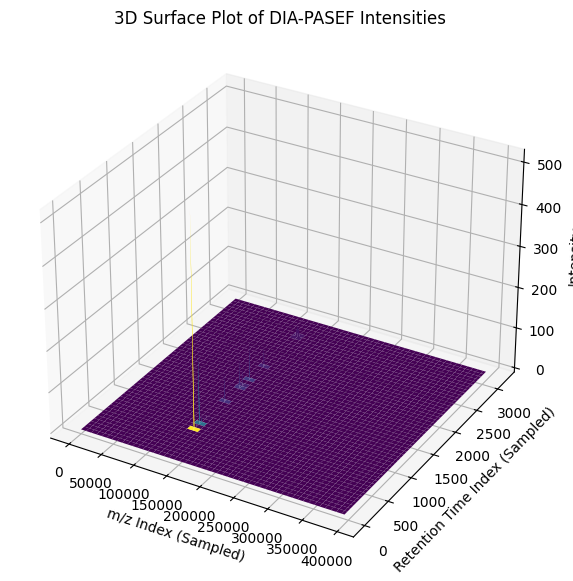

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define downsampling factors (Adjust as needed)
x_indices = np.linspace(0, intensities.shape[1] - 1, num=100, dtype=int)  # m/z index (sampled)
y_indices = np.linspace(0, intensities.shape[0] - 1, num=500, dtype=int)  # rt index (sampled)

# print(intensities)
print(x_indices)
# Create meshgrid for plotting
X, Y = np.meshgrid(x_indices, y_indices)

# Extract the downsampled intensity values
intensities_small = intensities[np.ix_(y_indices, x_indices)]

# Create 3D plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, intensities_small, cmap='viridis')

ax.set_xlabel("m/z Index (Sampled)")
ax.set_ylabel("Retention Time Index (Sampled)")
ax.set_zlabel("Intensity")
ax.set_title("3D Surface Plot of DIA-PASEF Intensities")

plt.show()


In [10]:
selected_precursor = data[:,:,0, 400.0: 425.0]
selected_precursor

,raw_indices,frame_indices,scan_indices,precursor_indices,push_indices,tof_indices,rt_values,rt_values_min,mobility_values,quad_low_mz_values,quad_high_mz_values,mz_values,intensity_values,corrected_intensity_values
0,3725,1,146,0,1074,127662,0.504660,0.008411,1.474541,-1.0,-1.0,404.242763,147,147
1,11663,1,206,0,1134,132644,0.504660,0.008411,1.407173,-1.0,-1.0,420.256525,80,80
2,13062,1,213,0,1141,130823,0.504660,0.008411,1.399315,-1.0,-1.0,414.367173,139,139
3,15065,1,222,0,1150,131141,0.504660,0.008411,1.389213,-1.0,-1.0,415.392632,10,10
4,17837,1,233,0,1161,131668,0.504660,0.008411,1.376867,-1.0,-1.0,417.094846,55,55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2539456,126975343,3176,33,0,2947361,126996,337.172372,5.619540,1.601499,-1.0,-1.0,402.125593,33,33
2539457,126975344,3176,33,0,2947361,127026,337.172372,5.619540,1.601499,-1.0,-1.0,402.220841,138,138
2539458,126975345,3176,33,0,2947361,128881,337.172372,5.619540,1.601499,-1.0,-1.0,408.132281,122,122
2539459,126975346,3176,33,0,2947361,129883,337.172372,5.619540,1.601499,-1.0,-1.0,411.343353,140,140
